# T1 mapping

### 5(3)3 MOLLI
- Signal = A-B*exp(-t/T1_app)
- T1 = T1_app*(B/A-1)

Estimated T1: 997.3 ms (True: 1000 ms), Best negative points: 3


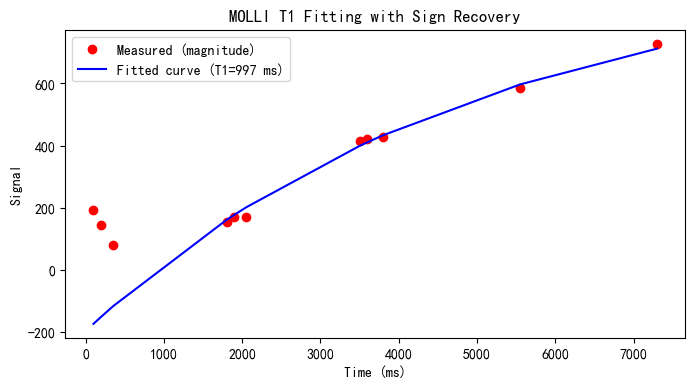

In [18]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 信号模型：y = A - B * exp(-t / T1_star)
def signal_model(t, A, B, T1_star):
    return A - B * np.exp(-t / T1_star)

# MOLLI T1 计算函数
def molli_t1_fit(t, signal, max_neg_points=5):
    """
    使用 Nekolla 符号恢复 + 三参数拟合 + MOLLI 校正
    :param t: 时间点数组 (秒 或 毫秒)
    :param signal: 幅值信号 (正数)
    :param max_neg_points: 最多尝试前几个点为负
    :return: T1 (ms), fit_curve, best_neg
    """
    best_chi2 = np.inf
    best_params = None
    best_neg = 0
    
    # 尝试不同符号分配
    for n_neg in range(max_neg_points + 1):
        y_signed = signal.copy()
        y_signed[:n_neg] *= -1  # 前 n_neg 个点设为负
        
        try:
            # 初始猜测
            A0 = np.max(y_signed) + 0.1
            B0 = A0 - np.min(y_signed)
            T1s0 = np.mean(t)  # 粗略估计
            
            popt, pcov = curve_fit(
                signal_model, t, y_signed,
                p0=[A0, B0, T1s0],
                bounds=([0, 0, 10], [np.inf, np.inf, 5000])  # T1* 范围合理限制
            )
            A_fit, B_fit, T1s_fit = popt
            
            # 计算残差和 chi2
            y_pred = signal_model(t, A_fit, B_fit, T1s_fit)
            residuals = y_signed - y_pred
            chi2 = np.sum(residuals**2)
            
            if chi2 < best_chi2:
                best_chi2 = chi2
                best_params = popt
                best_neg = n_neg
                
        except Exception as e:
            continue  # 拟合失败则跳过
    
    if best_params is None:
        raise RuntimeError("T1 fitting failed for all sign combinations.")
    
    A, B, T1_star = best_params
    # MOLLI 校正公式
    T1 = T1_star * (B / A - 1)
    
    fit_curve = signal_model(t, A, B, T1_star)
    return T1, fit_curve, best_neg

# 示例使用
if __name__ == "__main__":
    # 模拟 MOLLI 3-3-5 数据 (单位: ms)
    t_original = np.array([100, 1800, 3500, 200, 1900, 3600, 350, 2050, 3800, 5550, 7300])  # 累积时间
    true_T1 = 1000  # 真实T1 = 1000 ms
    A_true, B_true = 1000, 1200
    signal_clean = A_true - B_true * np.exp(-t_original / (true_T1 / (B_true/A_true - 1)))
    signal_magnitude = np.abs(signal_clean) + np.random.normal(0, 20, len(signal_clean))  # 加噪声
    
    # 排序（按时间）
    sort_idx = np.argsort(t_original)
    t_sorted = t_original[sort_idx]
    sig_sorted = signal_magnitude[sort_idx]
    
    # 计算 T1
    T1_est, fit_curve, n_neg = molli_t1_fit(t_sorted, sig_sorted)
    
    print(f"Estimated T1: {T1_est:.1f} ms (True: {true_T1} ms), Best negative points: {n_neg}")
    
    # 绘图
    plt.figure(figsize=(8, 4))
    plt.plot(t_sorted, sig_sorted, 'ro', label='Measured (magnitude)')
    plt.plot(t_sorted, fit_curve, 'b-', label=f'Fitted curve (T1={T1_est:.0f} ms)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Signal')
    plt.legend()
    plt.title('MOLLI T1 Fitting with Sign Recovery')
    plt.show()

### 5(1)1 MOLLI: shortened MOLLI

### SASHA--SAturation-recovery single-SHot Acquisition
- Signal = A(1-σexp(-TS/T1))

拟合结果: T1 = 492.18 ms, A = 1011.83, h = 0.97


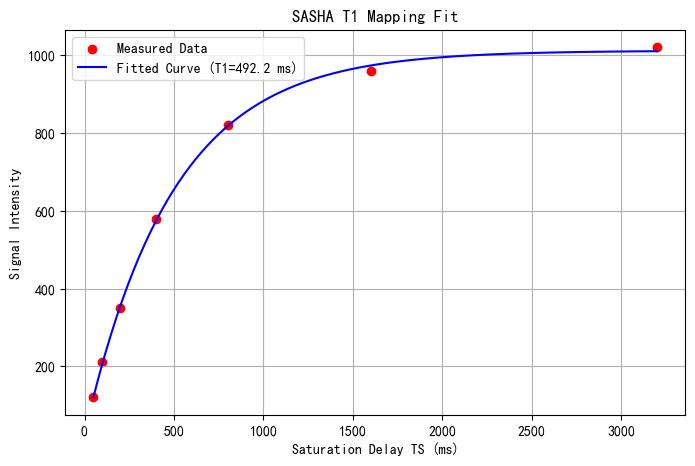

In [15]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# SASHA 信号模型函数
def sasha_model(TS, T1, A, h, D=0.0):
    """
    SASHA 信号模型：S(TS) = A * (1 - h * exp(-(TS - D) / T1)) + B
    参数:
        TS : 饱和恢复时间 (array-like)
        T1 : 纵向弛豫时间 (待拟合)
        A  : 信号缩放因子
        B  : 偏移（背景/噪声）
        h  : 饱和效率（可固定为1）
        D  : 采集延迟（可固定为0）
    """
    # 防止 TS - D < 0
    t_eff = np.maximum(TS - D, 0)
    return A * (1 - h * np.exp(-t_eff / T1))

# 示例数据（替换为你的真实数据）
TS_list = np.array([50, 100, 200, 400, 800, 1600, 3200])  # 单位：ms
signal = np.array([120, 210, 350, 580, 820, 960, 1020])   # 对应信号强度

# 固定参数（根据实验设置）
h_fixed = 1.0   # 假设饱和完全
D_fixed = 0.0   # 忽略采集延迟，或填入已知值（如 5 ms）

# 包装模型函数，固定 h 和 D
def model_fixed(TS, T1, A, h):
    return sasha_model(TS, T1, A, h, D=D_fixed)

# 初始猜测 [T1, A, B]
p0 = [1000, max(signal), 1]  # T1 初始猜 1000 ms

# 执行拟合
try:
    popt, pcov = curve_fit(model_fixed, TS_list, signal, p0=p0, bounds=([10, 0, 0.9], [5000, 2*max(signal), 1.1]))
    T1_est, A_est, h_est = popt
    print(f"拟合结果: T1 = {T1_est:.2f} ms, A = {A_est:.2f}, h = {h_est:.2f}")
    
    # 计算拟合曲线
    TS_fine = np.linspace(min(TS_list), max(TS_list), 100)
    signal_fit = model_fixed(TS_fine, *popt)
    
    # 绘图
    plt.figure(figsize=(8, 5))
    plt.scatter(TS_list, signal, color='red', label='Measured Data')
    plt.plot(TS_fine, signal_fit, 'b-', label=f'Fitted Curve (T1={T1_est:.1f} ms)')
    plt.xlabel('Saturation Delay TS (ms)')
    plt.ylabel('Signal Intensity')
    plt.legend()
    plt.grid(True)
    plt.title('SASHA T1 Mapping Fit')
    plt.show()
    

except RuntimeError as e:
    print("拟合失败:", e)

收敛于第 4 次迭代
真实参数: T1=1200.0, A=1000.0, B=1
估计参数: T1=1222.78, A=1010.38, B=1.00


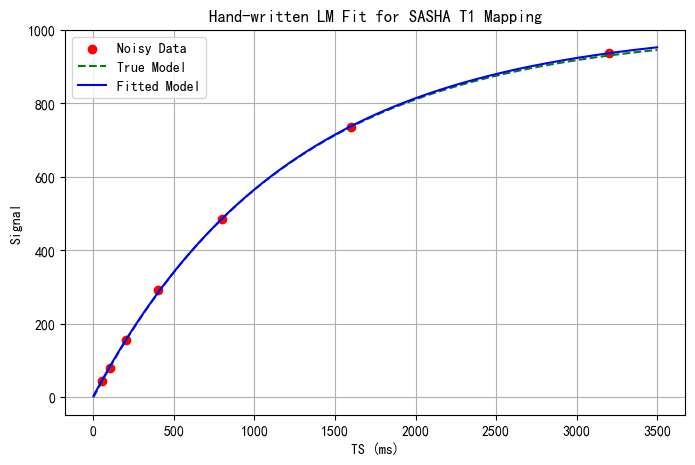

In [34]:
def sasha_model(params, TS):
    T1, A, Saturation = params
    if T1<=0:
        return np.full_like(TS, 1e10)
    return A*(1-Saturation*np.exp(-TS/T1))

def jacobian(params, TS):
    T1, A, Saturation = params
    J = np.zeros((len(TS), len(params)))
    exp_term = np.exp(-TS/T1)
    J[:,0] = -A*Saturation*exp_term*TS/T1**2
    J[:,1] = 1-Saturation*exp_term
    J[:,2] = -A*exp_term
    return J

def lm_fit(TS, signal, params_init, tol=1e-6, lambda_init=1e-3):
    """
     Levenberg-Marquardt 算法用于非线性最小二乘法
    """
    params = np.array(params_init, dtype=np.float64)
    lam = lambda_init

    for i in range(100):
        pred = sasha_model(params, TS)
        residuals = signal-pred # N*1
        ssr = np.sum(residuals**2)
        J = jacobian(params, TS)
        JT = J.T
        JTJ = JT @ J
        diag_JTJ = np.diag(JTJ)

        delta = np.linalg.solve(JTJ + lam*np.diag(diag_JTJ), JT @ residuals)

        # 尝试更新
        new_params = params + delta
        new_pred = sasha_model(new_params, TS)
        new_ssr = np.sum((signal - new_pred)**2)
        
        # 如果误差下降，接受更新并减小 λ
        if new_ssr < ssr:
            params = new_params
            lam = lam / 10.0
            improvement = ssr - new_ssr
            if improvement < tol:
                print(f"收敛于第 {i+1} 次迭代")
                break
        else:
            # 否则拒绝更新，增大 λ（更像梯度下降）
            lam = lam * 10.0
            
    return params

# ===== 示例使用 =====
# 真实参数（用于生成模拟数据）
T1_true, A_true, B_true = 1200.0, 1000.0, 1
TS = np.array([50, 100, 200, 400, 800, 1600, 3200], dtype=np.float64)

# 生成带噪声的信号
np.random.seed(42)
signal_clean = sasha_model([T1_true, A_true, B_true], TS)
noise = np.random.normal(0, 5, size=TS.shape)  # 噪声标准差 20
signal = signal_clean + noise
# 初始猜测
p0 = [1000.0, 900.0, 1]

# 执行手写 LM 拟合
params_est = lm_fit(TS, signal, p0)

print(f"真实参数: T1={T1_true}, A={A_true}, B={B_true}")
print(f"估计参数: T1={params_est[0]:.2f}, A={params_est[1]:.2f}, B={params_est[2]:.2f}")

# 可视化
TS_fine = np.linspace(0, 3500, 200)
plt.figure(figsize=(8, 5))
plt.scatter(TS, signal, color='red', label='Noisy Data')
plt.plot(TS_fine, sasha_model([T1_true, A_true, B_true], TS_fine), 'g--', label='True Model')
plt.plot(TS_fine, sasha_model(params_est, TS_fine), 'b-', label='Fitted Model')
plt.xlabel('TS (ms)')
plt.ylabel('Signal')
plt.legend()
plt.grid(True)
plt.title('Hand-written LM Fit for SASHA T1 Mapping')
plt.show()

# ECV

In [20]:
def ECV(Hct, T1_myo_pre, T1_myo_post, T1_blood_pre, T1_blood_post):
    delta_T1_myo = 1/T1_myo_post - 1/T1_myo_pre
    delta_T1_blood = 1/T1_blood_post - 1/T1_blood_pre
    return (1 - Hct)*delta_T1_myo/delta_T1_blood

In [22]:
ECV(0.45, 1000, 500, 1200, 300)

0.22

# T2 mapping
- S(TE)=S0*exp(-TE/T2)
- ln(S(TE)) = ln(S0)-TE/T2

In [24]:
# 取对数后进行线性拟合

# Perfusion

## MPRI

In [5]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

In [5]:
def compute_upslope(time, signal, baseline_frames=3, return_details=False):
    """
    计算 DCE-MRI 信号曲线的初始上升斜率（UpSlope）
    
    参数:
        time: 时间点数组 (单位: 秒), shape (N,)
        signal: 信号强度或浓度曲线, shape (N,)
        baseline_frames: 基线帧数（用于估计基线水平，默认前3帧）
        return_details: 是否返回绘图所需细节
    
    返回:
        up_slope: 初始上升斜率（单位: 1/s 或 %/s）
        details (可选): dict 包含 t_segment, s_segment, fitted_line, peak_idx, start_idx, end_idx
    """
    time = np.array(time)
    signal = np.array(signal)
    
    # 估计基线（前几帧平均）
    baseline = np.abs(np.mean(signal[:baseline_frames]))
    
    # 找到首过峰值（第一个显著峰值）
    peaks, _ = find_peaks(signal, height=np.percentile(signal, 90), distance=5)
    if len(peaks) == 0:
        raise ValueError("未检测到有效峰值，请检查信号质量")
    first_peak_idx = peaks[0]
    
    # 取从基线结束到第一个峰值之间的数据点
    start_idx = baseline_frames
    end_idx = first_peak_idx + 1  # 包含峰值点
    
    if end_idx <= start_idx:
        end_idx = min(start_idx + 5, len(signal))  # fallback
    
    t_segment = time[start_idx:end_idx]
    s_segment = signal[start_idx:end_idx]
    
    # 线性拟合
    slope, intercept = np.polyfit(t_segment, s_segment, deg=1)
    fitted_line = slope * t_segment + intercept
    
    if return_details:
        return slope, {
            't_segment': t_segment,
            's_segment': s_segment,
            'fitted_line': fitted_line,
            'peak_idx': first_peak_idx,
            'start_idx': start_idx,
            'end_idx': end_idx
        }
    else:
        return slope

In [9]:
def calculate_MPRI(
    time_rest, myocardium_signal_rest, LV_AIF_signal_rest,
    time_stress, myocardium_signal_stress, LV_AIF_signal_stress,
    return_plot_data=False
):
    """
    计算心肌灌注储备指数 MPRI
    
    参数:
        time_rest, time_stress: 时间轴 (秒)
        myocardium_signal_... : 心肌 ROI 平均信号强度
        LV_AIF_signal_...     : 左心室腔 AIF 信号强度
    
    返回:
        MPRI: 标量值
        details: 包含各斜率的字典（用于调试）
    """
    # 步骤1: 将信号转换为近似浓度（可选，但推荐）
    # c(t) ∝ ln(S(t)/S0)，这里 S0 取基线均值
    def signal_to_concentration(signal, baseline_frames=3):
        S0 = np.mean(signal[:baseline_frames])
        # 避免除零或负值
        ratio = np.clip(signal / S0, a_min=1e-3, a_max=None)
        return np.log(ratio)
    
    conc_myocardium_rest = signal_to_concentration(myocardium_signal_rest)
    conc_AIF_rest = signal_to_concentration(LV_AIF_signal_rest)
    conc_myocardium_stress = signal_to_concentration(myocardium_signal_stress)
    conc_AIF_stress = signal_to_concentration(LV_AIF_signal_stress)
    
    # 步骤2: 计算 UpSlope
    upslope_myocardium_rest, detail_myo_rest = compute_upslope(time_rest, conc_myocardium_rest, return_details=True)
    upslope_AIF_rest, detail_aif_rest  = compute_upslope(time_rest, conc_AIF_rest, return_details=True)
    
    upslope_myocardium_stress, detail_myo_stress = compute_upslope(time_stress, conc_myocardium_stress, return_details=True)
    upslope_AIF_stress, detail_aif_stress = compute_upslope(time_stress, conc_AIF_stress, return_details=True)
    
    # 步骤3: 归一化（心肌 / AIF）
    normalized_perfusion_rest = upslope_myocardium_rest / upslope_AIF_rest
    normalized_perfusion_stress = upslope_myocardium_stress / upslope_AIF_stress
    
    # 步骤4: 计算 MPRI
    MPRI = normalized_perfusion_stress / normalized_perfusion_rest
    
    details = {
        'upslope_myocardium_rest': upslope_myocardium_rest,
        'upslope_AIF_rest': upslope_AIF_rest,
        'upslope_myocardium_stress': upslope_myocardium_stress,
        'upslope_AIF_stress': upslope_AIF_stress,
        'normalized_rest': normalized_perfusion_rest,
        'normalized_stress': normalized_perfusion_stress
    }
    
    details = {
        'upslope_myocardium_rest': upslope_myocardium_rest,
        'upslope_AIF_rest': upslope_AIF_rest,
        'upslope_myocardium_stress': upslope_myocardium_stress,
        'upslope_AIF_stress': upslope_AIF_stress,
        'normalized_rest': normalized_perfusion_rest,
        'normalized_stress': normalized_perfusion_stress
    }
    
    if return_plot_data:
        plot_data = {
            'rest': {
                'myocardium': (time_rest, conc_myocardium_rest, detail_myo_rest),
                'AIF': (time_rest, conc_AIF_rest, detail_aif_rest)
            },
            'stress': {
                'myocardium': (time_stress, conc_myocardium_stress, detail_myo_stress),
                'AIF': (time_stress, conc_AIF_stress, detail_aif_stress)
            }
        }
        return MPRI, details, plot_data
    else:
        return MPRI, details

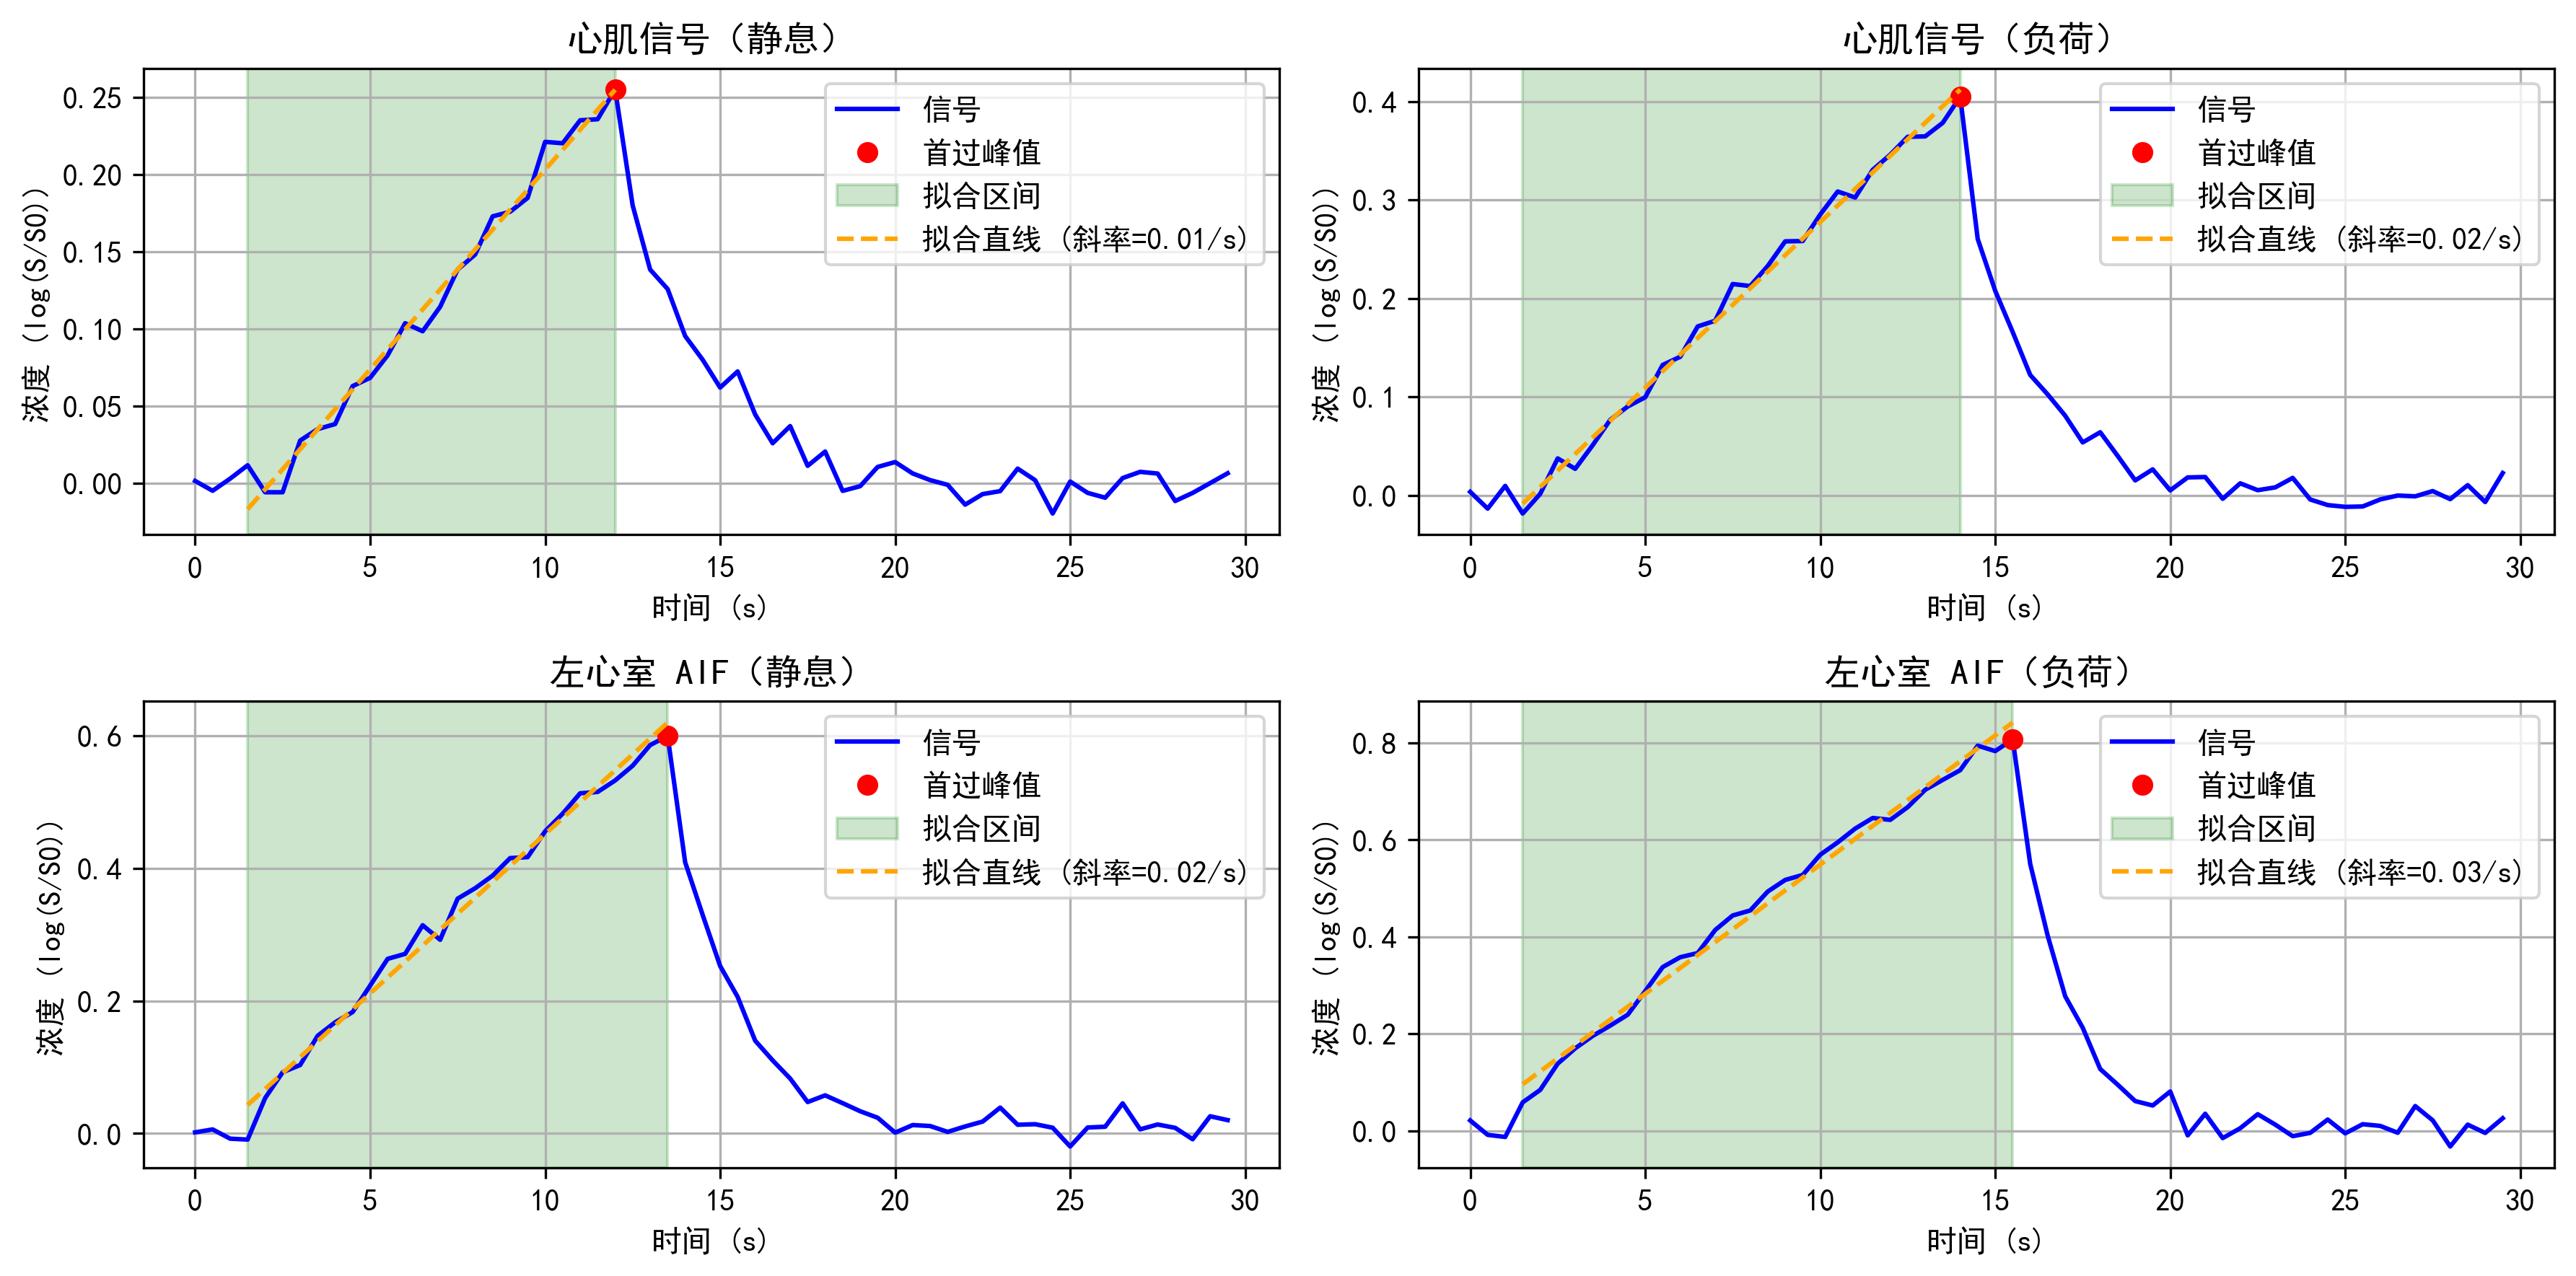

In [14]:
# 模拟时间点（例如每帧 0.5 秒，共 60 帧）
time_rest = np.arange(0, 30, 0.5)
time_stress = np.arange(0, 30, 0.5)

# 模拟信号（实际应来自 MRI ROI 平均）
np.random.seed(42)
myocardium_signal_rest = 1000 + np.concatenate([np.zeros(5), np.linspace(0, 300, 20), np.exp(-np.arange(35)*0.2)*200]) + np.random.normal(0, 10, 60)
LV_AIF_signal_rest = 1000 + np.concatenate([np.zeros(3), np.linspace(0, 800, 25), np.exp(-np.arange(32)*0.3)*500]) + np.random.normal(0, 15, 60)

myocardium_signal_stress = 1000 + np.concatenate([np.zeros(4), np.linspace(0, 500, 25), np.exp(-np.arange(31)*0.25)*300]) + np.random.normal(0, 10, 60)
LV_AIF_signal_stress = 1000 + np.concatenate([np.zeros(2), np.linspace(0, 1200, 30), np.exp(-np.arange(28)*0.4)*700]) + np.random.normal(0, 20, 60)

# === 计算 MPRI 并获取绘图数据 ===
MPRI, details, plot_data = calculate_MPRI(
    time_rest, myocardium_signal_rest, LV_AIF_signal_rest,
    time_stress, myocardium_signal_stress, LV_AIF_signal_stress,
    return_plot_data=True
)
# === 可视化 ===
fig, axes = plt.subplots(2, 2, figsize=(12, 6), dpi=300)
titles = [
    "心肌信号（静息）",
    "心肌信号（负荷）",
    "左心室 AIF（静息）",
    "左心室 AIF（负荷）"
]

data_keys = [('rest', 'myocardium'), ('stress', 'myocardium'), ('rest', 'AIF'), ('stress', 'AIF')]

for ax, title, (phase, tissue) in zip(axes.flat, titles, data_keys):
    time, signal, detail = plot_data[phase][tissue]
    
    ax.plot(time, signal, label='信号', color='blue')
    
    # 标出峰值
    peak_t = time[detail['peak_idx']]
    peak_s = signal[detail['peak_idx']]
    ax.plot(peak_t, peak_s, 'ro', label='首过峰值')
    
    # 高亮拟合区间
    ax.axvspan(time[detail['start_idx']], time[detail['end_idx']-1], color='green', alpha=0.2, label='拟合区间')
    
    # 绘制拟合直线
    ax.plot(detail['t_segment'], detail['fitted_line'], 'orange', linestyle='--', label=f'拟合直线 (斜率={detail["fitted_line"][1]-detail["fitted_line"][0]:.2f}/s)')
    
    ax.set_title(title)
    ax.set_xlabel('时间 (s)')
    ax.set_ylabel('浓度 (log(S/S0))')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## MBF

- 将MR信号s(t)转换后ga浓度c(t)
- 选择合适的AIF a(t)

In [6]:
# Onset检测法固定td
# 取前 N 帧（如前 5–10 帧）信号的均值和标准差
# 设定阈值=均值+2*标准差
# 找到第一个满足S>阈值的帧
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
def onset_detection(signal: np.ndarray, n_frames: int = 5):
    """
    使用Onset检测法检测信号的开始位置
    
    参数:
        signal: 输入信号数组
        n_frames: 前 n 帧用于计算均值和标准差
        
    返回:
        开始位置索引，如果没有找到开始位置则返回None
    """
    
    # 计算前 n 帧的均值和标准差
    mean = np.mean(signal[:n_frames])
    std = np.std(signal[:n_frames])
    
    # 设定阈值
    threshold = mean + 2 * std
    
    # 找到第一个满足S>阈值的帧
    for i in range(n_frames, len(signal)):
        if signal[i] > threshold:
            return i
    raise ValueError("没有找到开始位置")






=== 测试含时间延迟 t_d 的 Fermi 拟合 ===
真实 t_d: 2.500 s
Estimated t_d = 2.500 s (25 frames)
Converged at iter 50, cost: 0.102646
真实参数: F=1.200, t0=2.000, k=0.800
拟合参数: F=1.194, t0=2.000, k=0.798


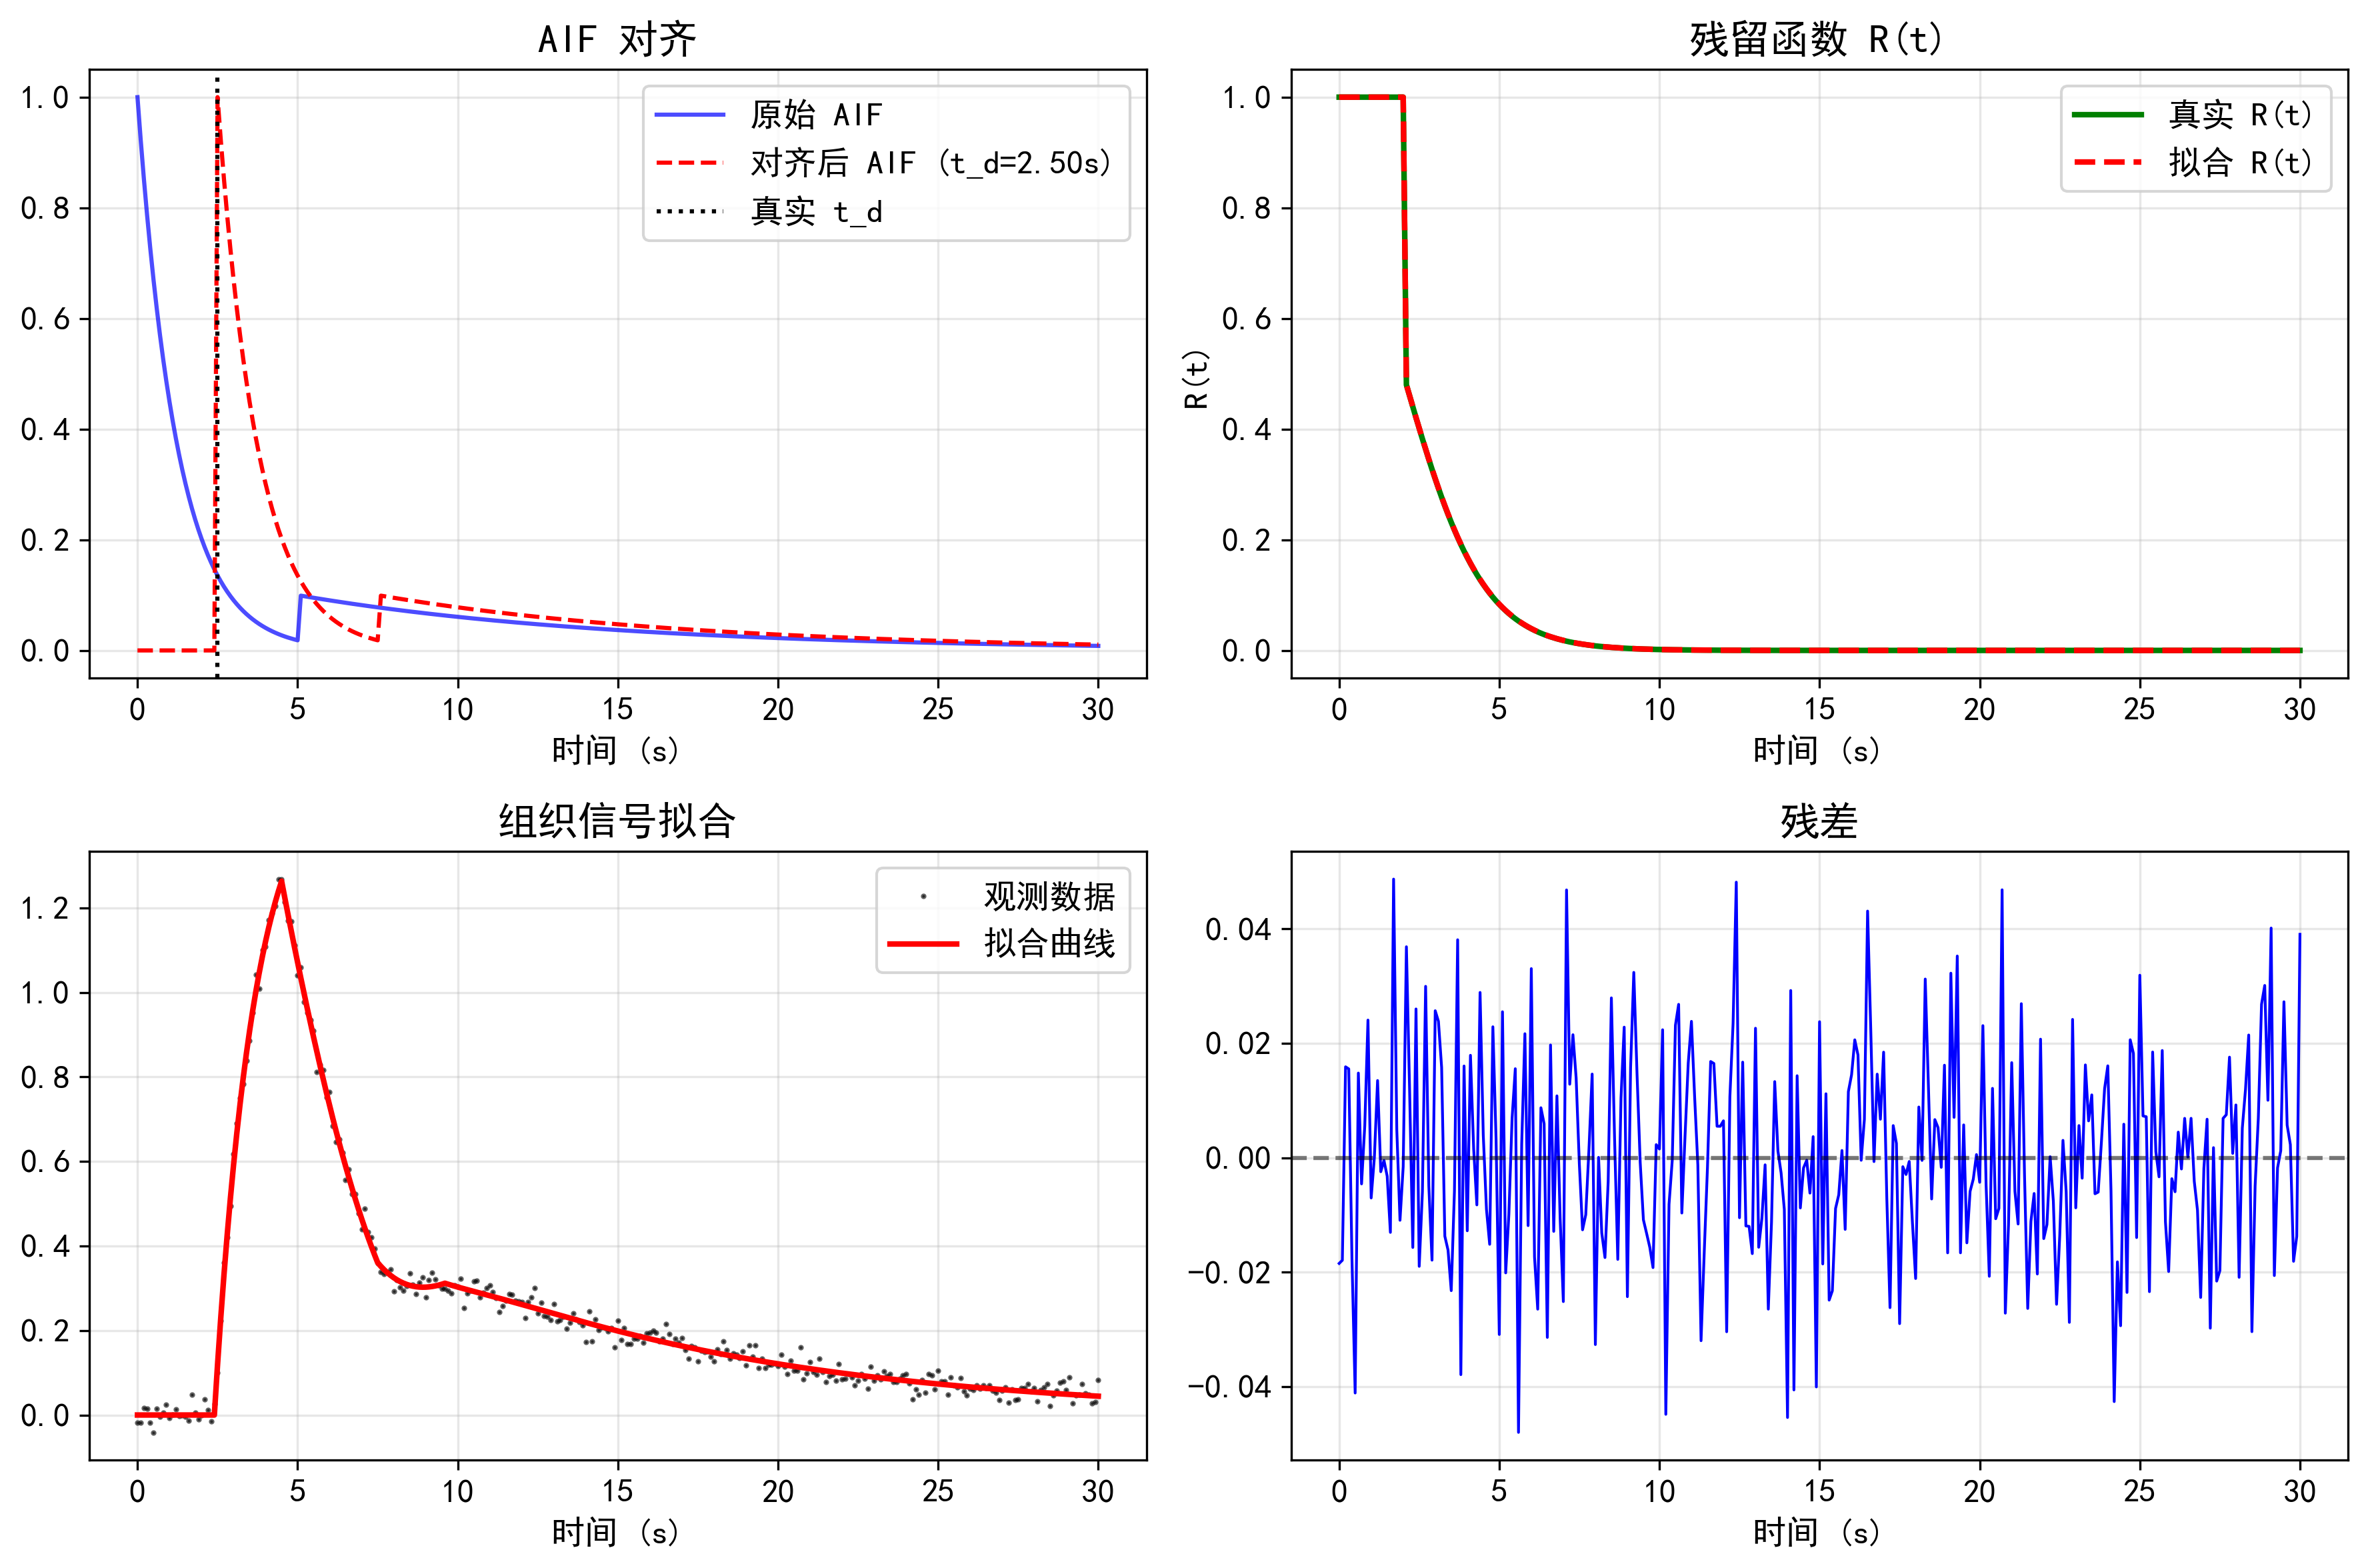

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def detect_onset(signal, baseline_frames=10, k_thresh=2.0):
    """检测信号起始时间（onset）"""
    baseline = signal[:baseline_frames]
    mu = np.mean(baseline)
    sigma = np.std(baseline)
    threshold = mu + k_thresh * sigma
    
    # 找第一个超过阈值的点
    above = np.where(signal > threshold)[0]
    if len(above) == 0:
        return 0
    return above[0]

def align_aif_with_delay(t, AIF, tissue_signal, dt):
    """估计 t_d 并返回对齐后的 AIF（在 tissue 时间轴上）"""
    onset_aif = detect_onset(AIF)
    onset_tissue = detect_onset(tissue_signal, k_thresh=3)
    
    # 计算延迟帧数（确保非负）
    delay_frames = max(0, onset_tissue - onset_aif)
    t_d = delay_frames * dt
    print(f"Estimated t_d = {t_d:.3f} s ({delay_frames} frames)")
    
    # 将 AIF 向右平移 delay_frames（即在 tissue 时间轴上对齐）
    aligned_AIF = np.zeros_like(AIF)
    if delay_frames < len(AIF):
        aligned_AIF[delay_frames:] = AIF[:-delay_frames] if delay_frames > 0 else AIF
    # 注意：也可以用插值实现亚像素对齐，但帧级对齐已足够
    
    return aligned_AIF, t_d

# Fermi 函数及其导数（保持不变）
def fermi_function(t, t0, k):
    result = np.ones_like(t)
    mask = t > t0
    exp_term = np.exp(k * (t[mask] - t0))
    result[mask] = 1.0 / (1.0 + exp_term)
    return result

def dR_dt0(t, t0, k):
    result = np.zeros_like(t)
    mask = t > t0
    exp_term = np.exp(k * (t[mask] - t0))
    result[mask] = k * exp_term / ((1.0 + exp_term)**2)
    return result

def dR_dk(t, t0, k):
    result = np.zeros_like(t)
    mask = t > t0
    exp_term = np.exp(k * (t[mask] - t0))
    result[mask] = -(t[mask] - t0) * exp_term / ((1.0 + exp_term)**2)
    return result

def compute_convolution(R, AIF, dt):
    return np.convolve(R, AIF, mode='full')[:len(R)] * dt

def compute_residual_and_jacobian(params, t, aligned_AIF, tissue_obs, dt):
    """注意：这里传入的是已对齐的 AIF（已包含 t_d 效应）"""
    F, t0, k = params
    
    R = fermi_function(t, t0, k)
    dR_dt0_vals = dR_dt0(t, t0, k)
    dR_dk_vals = dR_dk(t, t0, k)
    
    H = compute_convolution(R, aligned_AIF, dt)
    model = F * H
    residual = tissue_obs - model
    
    dH_dt0 = compute_convolution(dR_dt0_vals, aligned_AIF, dt)
    dH_dk = compute_convolution(dR_dk_vals, aligned_AIF, dt)
    
    J_F = -H
    J_t0 = -F * dH_dt0
    J_k = -F * dH_dk
    
    J = np.column_stack([J_F, J_t0, J_k])
    return residual, J

# LM 算法和拟合函数（保持不变，但调用时传入 aligned_AIF）
def lm_step(residual, J, lambda_reg):
    JTJ = J.T @ J
    A = JTJ + lambda_reg * np.eye(J.shape[1])
    JTr = J.T @ residual
    dx = np.linalg.solve(A, -JTr)
    return dx

def fermi_lm_fitting(t, aligned_AIF, tissue_obs, initial_params, dt=0.1, max_iter=100, tol=1e-6):
    params = np.array(initial_params)
    lambda_reg = 1e-3
    
    for iteration in range(max_iter):
        residual, J = compute_residual_and_jacobian(params, t, aligned_AIF, tissue_obs, dt)
        current_cost = np.sum(residual**2)
        
        dx = lm_step(residual, J, lambda_reg)
        new_params = params + dx
        
        new_residual, _ = compute_residual_and_jacobian(new_params, t, aligned_AIF, tissue_obs, dt)
        new_cost = np.sum(new_residual**2)
        
        if new_cost < current_cost:
            params = new_params
            lambda_reg *= 0.1
        else:
            lambda_reg *= 10
        
        if np.linalg.norm(dx) < tol:
            print(f"Converged at iter {iteration+1}, cost: {new_cost:.6f}")
            break
            
    return params

# 模拟数据（加入 t_d）
def simulate_data_with_td():
    t = np.linspace(0, 30, 301) # 0-30s，每 0.1 秒一个点
    dt = t[1] - t[0] # 时间间隔
    
    # 真实 t_d = 2.5 秒
    t_d_true = 2.5
    delay_frames = int(t_d_true / dt)
    
    # 生成原始 AIF（在 t=0 开始）
    AIF_raw = np.zeros_like(t)
    for i, ti in enumerate(t):
        if 0 <= ti <= 5:
            AIF_raw[i] = 1.0 * np.exp(-ti * 0.8) # 首过期
        elif ti > 5:
            AIF_raw[i] = 0.1 * np.exp(-(ti - 5) * 0.1) # 再循环/残留期
    
    # 生成 tissue 信号（使用真实参数）
    F_true, t0_true, k_true = 1.2, 2.0, 0.8
    R_true = fermi_function(t, t0_true, k_true)
    
    # 卷积时考虑 t_d：将 AIF 延迟
    AIF_delayed = np.zeros_like(AIF_raw)
    if delay_frames < len(AIF_raw):
        AIF_delayed[delay_frames:] = AIF_raw[:-delay_frames]
    
    true_conv = compute_convolution(R_true, AIF_delayed, dt)
    true_signal = F_true * true_conv
    
    # 加噪声
    noise = np.random.normal(0, 0.02, len(t))
    noisy_signal = true_signal + noise
    
    return t, AIF_raw, noisy_signal, [F_true, t0_true, k_true], t_d_true

# 主测试函数
def test_with_td():
    print("=== 测试含时间延迟 t_d 的 Fermi 拟合 ===")
    
    t, AIF_raw, tissue_obs, true_params, t_d_true = simulate_data_with_td()
    dt = t[1] - t[0]
    
    print(f"真实 t_d: {t_d_true:.3f} s")
    
    # 步骤1: 估计 t_d 并对齐 AIF
    aligned_AIF, t_d_est = align_aif_with_delay(t, AIF_raw, tissue_obs, dt)
    
    # 步骤2: 拟合（使用对齐后的 AIF）
    initial_params = [1.0, 1.5, 1.0]
    fitted_params = fermi_lm_fitting(t, aligned_AIF, tissue_obs, initial_params, dt=dt)
    
    print(f"真实参数: F={true_params[0]:.3f}, t0={true_params[1]:.3f}, k={true_params[2]:.3f}")
    print(f"拟合参数: F={fitted_params[0]:.3f}, t0={fitted_params[1]:.3f}, k={fitted_params[2]:.3f}")
    
    # 可视化
    # 设置字体大小为12
    plt.rcParams.update({'font.size': 12})
    plt.figure(figsize=(12, 8), dpi=300)
    
    plt.subplot(2, 2, 1)
    plt.plot(t, AIF_raw, 'b-', alpha=0.7, label='原始 AIF')
    plt.plot(t, aligned_AIF, 'r--', label=f'对齐后 AIF (t_d={t_d_est:.2f}s)')
    plt.axvline(t_d_true, color='k', linestyle=':', label='真实 t_d')
    plt.title('AIF 对齐')
    plt.xlabel('时间 (s)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.plot(t, fermi_function(t, true_params[1], true_params[2]), 'g-', label='真实 R(t)', linewidth=2)
    plt.plot(t, fermi_function(t, fitted_params[1], fitted_params[2]), 'r--', label='拟合 R(t)', linewidth=2)
    plt.title('残留函数 R(t)')
    plt.xlabel('时间 (s)')
    plt.ylabel('R(t)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 3)
    R_fit = fermi_function(t, fitted_params[1], fitted_params[2])
    fit_conv = compute_convolution(R_fit, aligned_AIF, dt)
    fit_signal = fitted_params[0] * fit_conv
    plt.plot(t, tissue_obs, 'k.', markersize=2, alpha=0.6, label='观测数据')
    plt.plot(t, fit_signal, 'r-', linewidth=2, label='拟合曲线')
    plt.title('组织信号拟合')
    plt.xlabel('时间 (s)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 4)
    residual = tissue_obs - fit_signal
    plt.plot(t, residual, 'b-', linewidth=1)
    plt.axhline(0, color='k', linestyle='--', alpha=0.5)
    plt.title('残差')
    plt.xlabel('时间 (s)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    test_with_td()

In [54]:
# LM算法与初始猜测值有关

## MBV

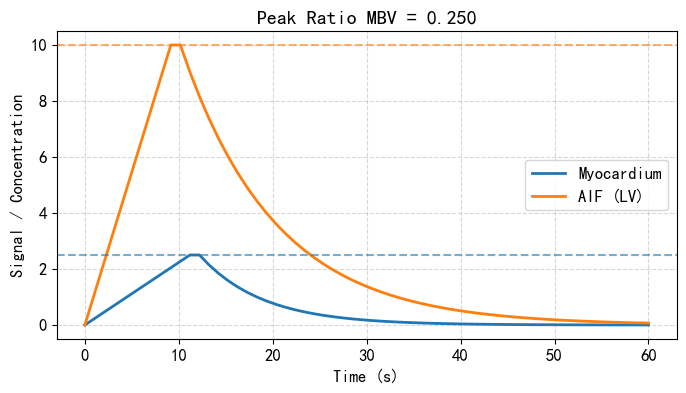

Estimated MBV (Peak Ratio) = 0.2500
Tissue peak = 2.50, AIF peak = 10.00


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def compute_mbv_peak_ratio(tissue_curve, aif_curve, time=None, plot=False):
    """
    使用峰值比法估算心肌血容量 (MBV)。
    
    参数:
        tissue_curve (array-like): 心肌组织的时间-信号/浓度曲线，形状 (N,)
        aif_curve (array-like): 动脉输入函数（如左心室），形状 (N,)
        time (array-like, optional): 时间点（秒），用于绘图，默认为 np.arange(N)
        plot (bool): 是否绘制曲线并标记峰值
    
    返回:
        mbv (float): 估算的 MBV（无量纲，相对值）
        tissue_peak (float): 组织峰值
        aif_peak (float): AIF 峰值
    """
    tissue_curve = np.asarray(tissue_curve)
    aif_curve = np.asarray(aif_curve)
    
    if tissue_curve.shape != aif_curve.shape:
        raise ValueError("tissue_curve 和 aif_curve 长度必须相同")
    
    # 找到峰值（最大值）
    tissue_peak = np.max(tissue_curve)
    aif_peak = np.max(aif_curve)
    
    # 避免除零
    if aif_peak <= 0:
        raise ValueError("AIF 峰值必须大于 0")
    
    mbv = tissue_peak / aif_peak
    
    if plot:
        if time is None:
            time = np.arange(len(tissue_curve))
        plt.figure(figsize=(8, 4))
        plt.plot(time, tissue_curve, label='Myocardium', linewidth=2)
        plt.plot(time, aif_curve, label='AIF (LV)', linewidth=2)
        plt.axhline(tissue_peak, color='C0', linestyle='--', alpha=0.6)
        plt.axhline(aif_peak, color='C1', linestyle='--', alpha=0.6)
        plt.title(f'Peak Ratio MBV = {mbv:.3f}')
        plt.xlabel('Time (s)')
        plt.ylabel('Signal / Concentration')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()
    
    return mbv, tissue_peak, aif_peak

# -----------------------------
# 示例使用
# -----------------------------
if __name__ == "__main__":
    # 模拟时间点（例如每 1 秒采样一次，共 60 点）
    time = np.linspace(0, 60, 60)
    
    # 模拟 AIF（左心室）：快速上升，缓慢下降
    aif = np.zeros_like(time)
    idx_aif_peak = 10  # 峰值在第10秒
    aif[:idx_aif_peak] = np.linspace(0, 10, idx_aif_peak)
    aif[idx_aif_peak:] = 10 * np.exp(-0.1 * (time[idx_aif_peak:] - time[idx_aif_peak]))
    
    # 模拟心肌组织曲线：峰值较低，稍延迟
    tissue = np.zeros_like(time)
    idx_tissue_peak = 12
    tissue[:idx_tissue_peak] = np.linspace(0, 2.5, idx_tissue_peak)
    tissue[idx_tissue_peak:] = 2.5 * np.exp(-0.15 * (time[idx_tissue_peak:] - time[idx_tissue_peak]))
    
    # 计算 MBV
    mbv, t_peak, a_peak = compute_mbv_peak_ratio(
        tissue_curve=tissue,
        aif_curve=aif,
        time=time,
        plot=True
    )
    
    print(f"Estimated MBV (Peak Ratio) = {mbv:.4f}")
    print(f"Tissue peak = {t_peak:.2f}, AIF peak = {a_peak:.2f}")